# Live Benchmark — online-retail dataset (k=2)

Sweep `min_support` and `min_confidence` side by side — compare **efficient-apriori** vs **fastapriori (polars)** on execution time and rule counts.

In [3]:
import time, gc, tracemalloc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fastapriori import find_associations
from efficient_apriori import apriori

# Load data
df = pd.read_csv("online-retail.csv")
print(f"Rows: {len(df):,}")
print(f"Unique invoices: {df['Invoice'].nunique():,}")
print(f"Unique items: {df['StockCode'].nunique():,}")

# Prepare efficient-apriori input (list of tuples)
transactions = df.groupby("Invoice")["StockCode"].apply(lambda x: tuple(set(x))).tolist()        
print(f"Transactions: {len(transactions):,}")

Rows: 525,461
Unique invoices: 28,816
Unique items: 4,632
Transactions: 28,816


In [4]:
def bench(fn):
    """Run fn() with GC. Returns (result, time_s)."""
    gc.collect()
    t0 = time.perf_counter()
    result = fn()
    elapsed = time.perf_counter() - t0
    return result, elapsed

In [5]:
# log_array_10 = np.logspace(start=-4, stop=-2, num=10)
# print(log_array_10)

In [7]:
#support_values

In [37]:
#fa_rules

In [8]:
# --- Sweep min_support (fixed min_confidence=0.0) ---
support_values = np.logspace(start=-4, stop=-2, num=10)
support_results = []

for i, s in enumerate(support_values):
    print(f"[{i+1}/10] min_support={s:.4f} ... ", end="", flush=True)

    fa_res, fa_time = bench(
        lambda s=s: find_associations(
            df, transaction_col="Invoice", item_col="StockCode",
            min_support=s, min_confidence=0.0, backend="polars",
        )
    )
    ea_res, ea_time = bench(
        lambda s=s: apriori(transactions, min_support=s, min_confidence=0.0, max_length=2)
    )

    fa_rules = len(fa_res)
    ea_itemsets, ea_rules_obj = ea_res
    ea_rules = len(ea_rules_obj)

    support_results.append({
        "support": round(s, 4),
        "fa_time": round(fa_time, 2),
        "ea_time": round(ea_time, 2),
        "fa_rules": fa_rules,
        "ea_rules": ea_rules,
    })
    print(f"fa={fa_time:.2f}s  ea={ea_time:.2f}s  fa_rules={fa_rules}  ea_rules={ea_rules}")

# --- Sweep min_confidence (fixed min_support=0.001) ---
confidence_values = np.linspace(0.05, 0.50, 10)
fixed_support = 0.001
confidence_results = []

for i, c in enumerate(confidence_values):
    print(f"[{i+1}/10] min_confidence={c:.2f} ... ", end="", flush=True)

    fa_res, fa_time = bench(
        lambda c=c: find_associations(
            df, transaction_col="Invoice", item_col="StockCode",
            min_support=fixed_support, min_confidence=c, backend="polars",
        )
    )
    ea_res, ea_time = bench(
        lambda c=c: apriori(transactions, min_support=fixed_support, min_confidence=c, max_length=2)
    )

    fa_rules = len(fa_res)
    ea_itemsets, ea_rules_obj = ea_res
    ea_rules = len(ea_rules_obj)

    confidence_results.append({
        "confidence": round(c, 4),
        "fa_time": round(fa_time, 2),
        "ea_time": round(ea_time, 2),
        "fa_rules": fa_rules,
        "ea_rules": ea_rules,
    })
    print(f"fa={fa_time:.2f}s  ea={ea_time:.2f}s  fa_rules={fa_rules}  ea_rules={ea_rules}")

print("Done!")

[1/10] min_support=0.0001 ... fa=10.99s  ea=63.10s  fa_rules=3678982  ea_rules=3678982
[2/10] min_support=0.0002 ... fa=10.47s  ea=49.96s  fa_rules=2383106  ea_rules=2383106
[3/10] min_support=0.0003 ... fa=10.66s  ea=40.99s  fa_rules=1280742  ea_rules=1280742
[4/10] min_support=0.0005 ... fa=9.55s  ea=32.95s  fa_rules=720188  ea_rules=720188
[5/10] min_support=0.0008 ... fa=10.33s  ea=25.45s  fa_rules=325620  ea_rules=325620
[6/10] min_support=0.0013 ... fa=10.78s  ea=19.05s  fa_rules=122042  ea_rules=122042
[7/10] min_support=0.0022 ... fa=9.83s  ea=13.43s  fa_rules=36456  ea_rules=36456
[8/10] min_support=0.0036 ... fa=9.99s  ea=8.83s  fa_rules=9232  ea_rules=9232
[9/10] min_support=0.0060 ... fa=9.78s  ea=4.55s  fa_rules=2036  ea_rules=2036
[10/10] min_support=0.0100 ... fa=10.00s  ea=2.26s  fa_rules=418  ea_rules=418
[1/10] min_confidence=0.05 ... fa=10.05s  ea=22.82s  fa_rules=176582  ea_rules=176582
[2/10] min_confidence=0.10 ... fa=10.38s  ea=21.33s  fa_rules=99230  ea_rules=99

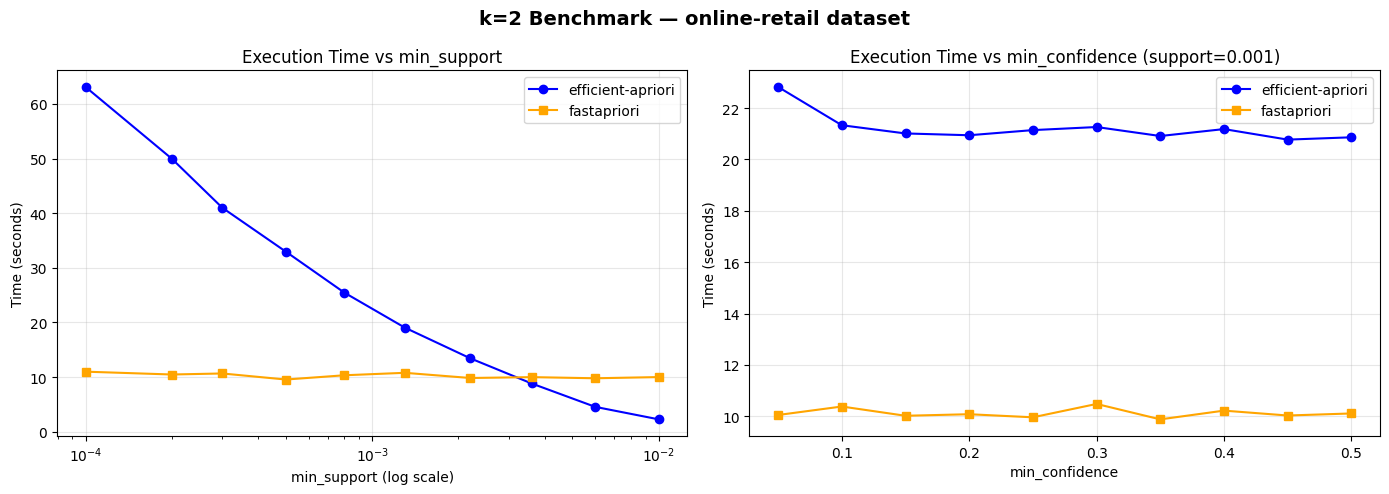

In [10]:
sup_df = pd.DataFrame(support_results)
conf_df = pd.DataFrame(confidence_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("k=2 Benchmark — online-retail dataset", fontsize=14, fontweight="bold")

# Top-left — Time vs min_support
axes[0].plot(sup_df["support"], sup_df["ea_time"], color="blue", marker="o", label="efficient-apriori")
axes[0].plot(sup_df["support"], sup_df["fa_time"], color="orange", marker="s", label="fastapriori")
axes[0].set_xlabel("min_support (log scale)")
axes[0].set_ylabel("Time (seconds)")
axes[0].set_title("Execution Time vs min_support")
axes[0].set_xscale("log")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# # Top-right — Rules vs min_support
# axes[0, 1].plot(sup_df["support"], sup_df["ea_rules"], color="blue", marker="o", label="efficient-apriori")
# axes[0, 1].plot(sup_df["support"], sup_df["fa_rules"], color="orange", marker="s", label="fastapriori")
# axes[0, 1].set_xlabel("min_support (log scale)")
# axes[0, 1].set_ylabel("Number of Rules")
# axes[0, 1].set_title("Rule Count vs min_support")
# axes[0, 1].set_xscale("log")
# axes[0, 1].legend()
# axes[0, 1].grid(True, alpha=0.3)

# Bottom-left — Time vs min_confidence
axes[1].plot(conf_df["confidence"], conf_df["ea_time"], color="blue", marker="o", label="efficient-apriori")
axes[1].plot(conf_df["confidence"], conf_df["fa_time"], color="orange", marker="s", label="fastapriori")
axes[1].set_xlabel("min_confidence")
axes[1].set_ylabel("Time (seconds)")
axes[1].set_title(f"Execution Time vs min_confidence (support={fixed_support})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
             
# # Bottom-right — Rules vs min_confidence
# axes[1, 1].plot(conf_df["confidence"], conf_df["ea_rules"], color="blue", marker="o", label="efficient-apriori")
# axes[1, 1].plot(conf_df["confidence"], conf_df["fa_rules"], color="orange", marker="s", label="fastapriori")
# axes[1, 1].set_xlabel("min_confidence")
# axes[1, 1].set_ylabel("Number of Rules")
# axes[1, 1].set_title(f"Rule Count vs min_confidence (support={fixed_support})")
# axes[1, 1].legend()
# axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("retail_support_confidence_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# res_df["speedup"] = (res_df["ea_time"] / res_df["fa_time"]).round(1)
# res_df

In [12]:
sup_df

,support,fa_time,ea_time,fa_rules,ea_rules
0,0.0001,10.99,63.10,3678982,3678982
1,0.0002,10.47,49.96,2383106,2383106
2,0.0003,10.66,40.99,1280742,1280742
3,0.0005,9.55,32.95,720188,720188
4,0.0008,10.33,25.45,325620,325620
5,0.0013,10.78,19.05,122042,122042
6,0.0022,9.83,13.43,36456,36456
7,0.0036,9.99,8.83,9232,9232
8,0.0060,9.78,4.55,2036,2036
9,0.0100,10.00,2.26,418,418


In [14]:
conf_df

,confidence,fa_time,ea_time,fa_rules,ea_rules
0,0.05,10.05,22.82,176582,176582
1,0.10,10.38,21.33,99230,99230
2,0.15,10.02,21.01,53611,53611
3,0.20,10.08,20.94,30838,30838
4,0.25,9.96,21.14,18252,18252
5,0.30,10.48,21.26,10810,10810
6,0.35,9.88,20.91,6630,6630
7,0.40,10.22,21.18,4248,4248
8,0.45,10.03,20.77,2711,2711
9,0.50,10.11,20.86,1728,1728
